# TD02 — Réseau mono-couche (3 perceptrons)

In [6]:
# EXPORT
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field

In [7]:
# EXPORT
def gen_blobs(n=25, sigma=0.6, seed=0):
    rng = np.random.default_rng(seed)
    centres = [(-2,-2),(2,-2),(0,2)]
    X_list, y_list = [], []
    for k,(cx,cy) in enumerate(centres):
        pts = rng.normal(loc=(cx,cy), scale=sigma, size=(n,2))
        X_list.append(pts)
        y_list += [k]*n
    return np.vstack(X_list), np.array(y_list)

def gen_piege(n_centre=15, seed=1):
    rng = np.random.default_rng(seed)
    Xc0 = rng.normal(loc=(0,0), scale=0.6, size=(n_centre,2))
    Xc1 = rng.normal(loc=(0,0), scale=0.6, size=(n_centre,2))
    Xc = np.vstack([Xc0, Xc1])
    yc = np.array([0]*n_centre + [1]*n_centre)
    return Xc, yc

In [8]:
# EXPORT
X_train, y_train = gen_blobs()
X_piege, y_piege = gen_piege()
X_dur = np.vstack([X_train, X_piege])
y_dur = np.concatenate([y_train, y_piege])

In [16]:
# EXPORT
def display_data(X, y, titre):
    couleurs = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
    fig, ax = plt.subplots()
    for k in sorted(set(y)):
        ax.scatter(
            X[y == k, 0], X[y == k, 1],
            c=couleurs[k % len(couleurs)],
            edgecolors='k', s=25, label=f"classe {k}"
        )
    ax.set_aspect('equal')
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(f"{titre} ({len(X)} pts)")
    ax.legend()
    ax.grid(True)
    plt.show()

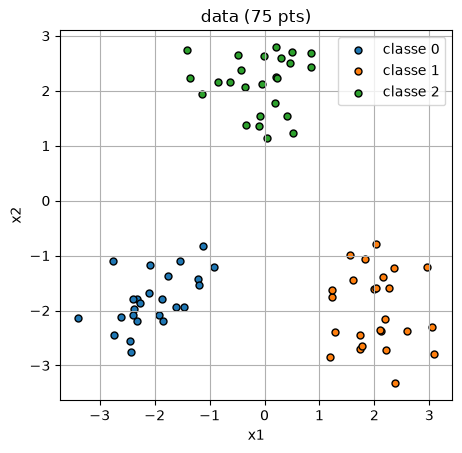

In [19]:
display_data(X_train, y_train, "data")

In [9]:
# EXPORT
from dataclasses import dataclass
import numpy as np

@dataclass
class CoucheMonoCouche:
    W: np.ndarray
    b: np.ndarray
    # SKIP
    def predict(self, x: np.ndarray) -> int:
        h = self.W @ x + self.b
        return int(np.argmax(h))

    def learn_one(self, x: np.ndarray, t: int, r: float = 0.1):
        p = self.predict(x)
        if p != t:
            self.W[t] += r * x
            self.b[t] += r
            self.W[p] -= r * x
            self.b[p] -= r

    def train(self, X: np.ndarray, y: np.ndarray, epochs: int = 50):
        for _ in range(epochs):
            err = 0
            for xi, ti in zip(X, y):
                if self.predict(xi) != int(ti):
                    err += 1
                self.learn_one(xi, int(ti))
            if err == 0:
                break
        return self

In [10]:
# EXPORT
couche = CoucheMonoCouche(W=np.zeros((3,2)), b=np.zeros(3))
couche.train(X_train, y_train)
pred_train = np.array([couche.predict(x) for x in X_train])
print(f"accuracy train separable: {(pred_train==y_train).mean()*100:.1f}%")
couche_dur = CoucheMonoCouche(W=np.zeros((3,2)), b=np.zeros(3))
couche_dur.train(X_dur, y_dur)
pred_dur = np.array([couche_dur.predict(x) for x in X_dur])
print(f"accuracy avec piege: {(pred_dur==y_dur).mean()*100:.1f}%")

accuracy train separable: 100.0%
accuracy avec piege: 74.3%


In [11]:
# EXPORT
def plot_frontieres(ax, X, y, couche, lim=(-4,4)):
    xx, yy = np.meshgrid(np.linspace(lim[0],lim[1],300), np.linspace(lim[0],lim[1],300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = np.argmax(grid @ couche.W.T + couche.b, axis=1).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-0.5,0.5,1.5,2.5], colors=['tab:blue','tab:orange','tab:green'], alpha=0.12)
    for k,c in enumerate(['tab:blue','tab:orange','tab:green']):
        ax.scatter(X[y==k,0], X[y==k,1], c=c, edgecolors='k', s=25, label=f"classe {k}")
    # zeros de chaque h_k (indicatif) — les vraies frontieres argmax sont h_k == max autres, visibles via le fond colore
    for k in range(3):
        H = (grid @ couche.W[k] + couche.b[k]).reshape(xx.shape)
        ax.contour(xx, yy, H, levels=[0], colors='k', linewidths=1.5, linestyles='--')
    ax.set_aspect('equal'); ax.legend(); ax.grid(True)

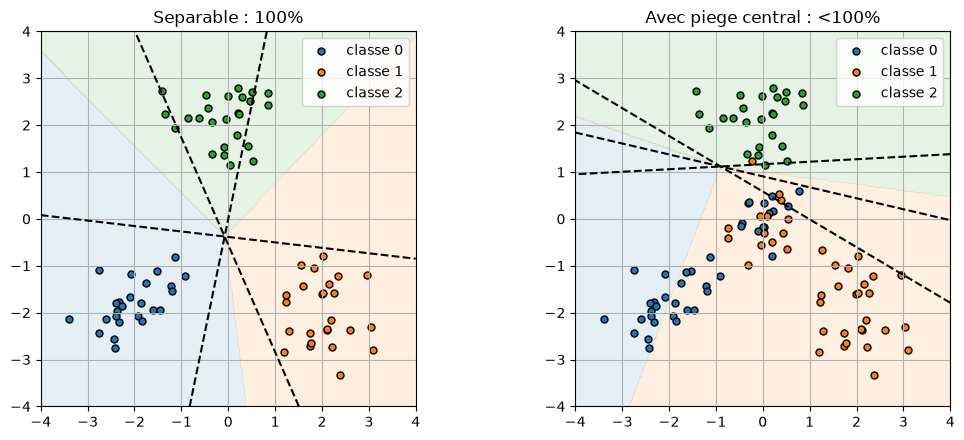

In [12]:
# EXPORT
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
plot_frontieres(axes[0], X_train, y_train, couche)
axes[0].set_title("Separable : 100%")
plot_frontieres(axes[1], X_dur, y_dur, couche_dur)
axes[1].set_title("Avec piege central : <100%")
plt.tight_layout()
plt.show()

In [13]:
# EXPORT
TPL = {
 0: np.array([0,1,0,1,0, 1,0,1,0,1, 1,1,1,1,1, 1,0,0,0,1, 1,0,0,0,1]),
 1: np.array([1,1,1,0,0, 1,0,0,1,0, 1,1,1,0,0, 1,0,0,1,0, 1,1,1,0,0]),
 2: np.array([0,1,1,1,0, 1,0,0,0,0, 1,0,0,0,0, 1,0,0,0,0, 0,1,1,1,0]),
}
def enc(v): return np.where(v==1, 1.0, -1.0)
def gen_lettres(n_per=10, n_flip=2, seed=2):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for k in range(3):
        base = enc(TPL[k])
        for _ in range(n_per):
            w = base.copy()
            idx = rng.choice(25, size=n_flip, replace=False)
            w[idx] *= -1
            X.append(w); y.append(k)
    return np.array(X), np.array(y)

In [14]:
# EXPORT
X_let, y_let = gen_lettres()
c_let = CoucheMonoCouche(W=np.zeros((3,25)), b=np.zeros(3))
c_let.train(X_let, y_let)
pred_let = np.array([c_let.predict(x) for x in X_let])
print(f"accuracy lettres train: {(pred_let==y_let).mean()*100:.1f}%")
X_let_test, y_let_test = gen_lettres(n_per=10, n_flip=5, seed=99)
pred_test = np.array([c_let.predict(x) for x in X_let_test])
print(f"accuracy lettres test flip5: {(pred_test==y_let_test).mean()*100:.1f}%")

accuracy lettres train: 100.0%
accuracy lettres test flip5: 73.3%


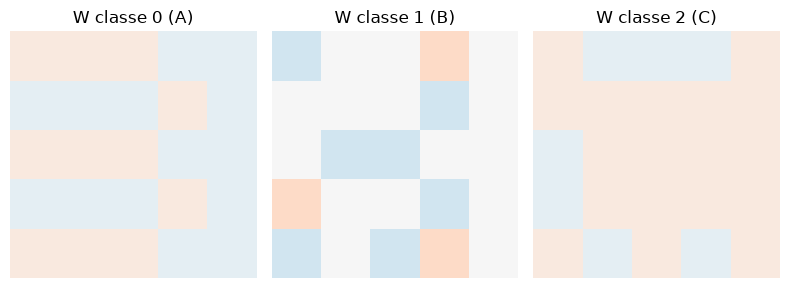

In [15]:
# EXPORT
fig, axes = plt.subplots(1, 3, figsize=(8,3))
for k in range(3):
    axes[k].imshow(c_let.W[k].reshape(5,5), cmap="RdBu", vmin=-1, vmax=1)
    axes[k].set_title(f"W classe {k} ({'ABC'[k]})")
    axes[k].axis("off")
plt.tight_layout()
plt.show()